# Task 2: Predicting Apple Stock Closing Price

The idea here is: given today's Open, High, Low, and Volume, can we predict what the closing price will be?

This is a classic regression problem. I'm using Apple (AAPL) stock data from 2022 to 2024. The goal is to train a model, evaluate how well it does, and then plot the actual vs predicted prices to see how close we got.

I'm going to try two models — Linear Regression (simple baseline) and Random Forest (more powerful) — and compare them.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# try loading from yfinance first, fall back to local CSV if blocked
try:
    import yfinance as yf
    df = yf.download('AAPL', start='2022-01-01', end='2024-12-31', progress=False)
    df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]
    if df.empty:
        raise ValueError('empty')
    df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
    print('loaded live data from yfinance')
except Exception:
    df = pd.read_csv('AAPL.csv', index_col='Date', parse_dates=True)
    print('loaded local AAPL data (yfinance unavailable in this environment)')

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110

print(f'dataset: {df.shape[0]} trading days')
df.tail()

Failed to get ticker 'AAPL' reason: Expecting value: line 1 column 1 (char 0)


HTTP Error 403: Host not in allowlist


HTTP Error 403: Host not in allowlist



1 Failed download:


['AAPL']: TypeError("argument of type 'NoneType' is not iterable")


loaded local AAPL data (yfinance unavailable in this environment)
dataset: 782 trading days


,Open,High,Low,Close,Volume
Date,,,,,
2024-12-25,165.44,166.13,163.97,164.46,66380660.0
2024-12-26,163.60,164.19,163.25,163.77,72004757.0
2024-12-27,163.59,164.09,163.45,163.60,85272994.0
2024-12-30,164.99,166.00,164.25,165.48,83300239.0
2024-12-31,164.45,168.21,162.57,166.06,90769841.0


## Quick look at the data

In [2]:
print('Shape:', df.shape)
print('\nAny missing values?')
print(df.isnull().sum())

Shape: (782, 5)

Any missing values?
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


In [3]:
df.describe().round(2)

,Open,High,Low,Close,Volume
count,782.00,782.00,782.00,782.00,7.820000e+02
mean,171.67,172.70,170.54,171.60,8.542344e+07
std,21.63,21.76,21.52,21.62,2.012547e+07
min,135.95,136.63,134.88,135.63,5.002165e+07
25%,155.95,156.75,155.01,155.77,6.904874e+07
50%,167.18,168.22,166.42,167.14,8.467233e+07
75%,187.68,188.80,186.58,187.58,1.029935e+08
max,239.08,241.99,238.38,240.28,1.199362e+08


### Plotting the closing price over time

Before doing any modeling, let's just look at how the stock has moved over the 3 years.

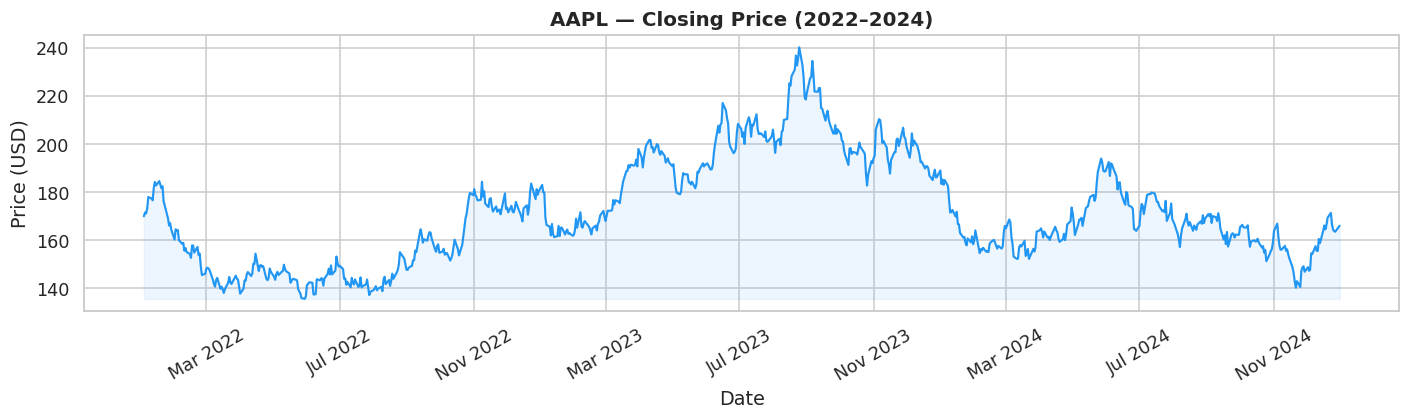

In [4]:
fig, ax = plt.subplots(figsize=(13, 4))

ax.plot(df.index, df['Close'], color='#2196F3', linewidth=1.4, label='Close Price')
ax.fill_between(df.index, df['Close'], df['Close'].min(), alpha=0.08, color='#2196F3')

ax.set_title('AAPL — Closing Price (2022–2024)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('stock_history.png', bbox_inches='tight')
plt.show()

## Feature Engineering

Right now our features are just Open, High, Low, Volume. But in stock data, context matters — what happened yesterday affects today. So I'm adding some extra features that give the model more information to work with:

- **Lag features** → yesterday's close, 2 days ago close, etc.
- **Rolling averages** → 5-day and 10-day moving averages (smoothed trend)
- **Daily range** → High minus Low (measures volatility on that day)
- **Gap** → difference between today's Open and yesterday's Close (shows overnight movement)

These kinds of features are very commonly used in financial ML.

In [5]:
df_feat = df.copy()

# lag features — what was the close 1, 2, 3 days ago?
for lag in [1, 2, 3]:
    df_feat[f'Close_lag{lag}'] = df_feat['Close'].shift(lag)

# rolling averages — smoothed trend over last 5 and 10 days
df_feat['MA5']  = df_feat['Close'].shift(1).rolling(5).mean()
df_feat['MA10'] = df_feat['Close'].shift(1).rolling(10).mean()

# daily range — how much did the price swing today?
df_feat['Daily_range'] = df_feat['High'] - df_feat['Low']

# overnight gap — did the price jump up/down from yesterday's close to today's open?
df_feat['Gap'] = df_feat['Open'] - df_feat['Close'].shift(1)

# drop rows with NaN (from the shifts and rolling windows)
df_feat.dropna(inplace=True)

print('features ready, shape:', df_feat.shape)
df_feat[['Close', 'Close_lag1', 'MA5', 'MA10', 'Daily_range', 'Gap']].head()

features ready, shape: (772, 12)


,Close,Close_lag1,MA5,MA10,Daily_range,Gap
Date,,,,,,
2022-01-17,184.63,182.79,180.562,176.686,1.95,1.99
2022-01-18,183.15,184.63,182.018,178.149,1.12,-1.29
2022-01-19,181.66,183.15,183.318,179.307,1.12,-2.41
2022-01-20,182.51,181.66,183.304,180.353,4.50,0.06
2022-01-21,176.28,182.51,182.948,181.280,2.41,-5.49


## Splitting into features (X) and target (y)

The target is the **Close** price. Everything else goes into X as input features.

One important thing with time series: I'm **not shuffling** the data before splitting. I'm keeping the last 20% of time as the test set — this is how it works in real life, you train on past data and predict future data.

In [6]:
feature_cols = ['Open', 'High', 'Low', 'Volume',
                'Close_lag1', 'Close_lag2', 'Close_lag3',
                'MA5', 'MA10', 'Daily_range', 'Gap']

X = df_feat[feature_cols]
y = df_feat['Close']

# keeping time order — no shuffle!
split = int(len(X) * 0.80)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f'training on {len(X_train)} days, testing on {len(X_test)} days')
print(f'test period: {X_test.index[0].date()} to {X_test.index[-1].date()}')

training on 617 days, testing on 155 days
test period: 2024-05-29 to 2024-12-31


In [7]:
# scaling the features — linear regression is sensitive to scale
# random forest doesn't strictly need this but it doesn't hurt
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

## Model 1: Linear Regression

Starting simple. Linear regression tries to find a straight-line relationship between the features and the target. It's fast, interpretable, and a good baseline to beat.

In [8]:
lr = LinearRegression()
lr.fit(X_train_sc, y_train)

y_pred_lr = lr.predict(X_test_sc)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print('--- Linear Regression Results ---')
print(f'MAE  : ${mae_lr:.2f}  (on average, off by this many dollars)')
print(f'RMSE : ${rmse_lr:.2f}  (penalizes bigger errors more)')
print(f'R²   : {r2_lr:.4f}  (1.0 = perfect, higher is better)')

--- Linear Regression Results ---
MAE  : $0.39  (on average, off by this many dollars)
RMSE : $0.49  (penalizes bigger errors more)
R²   : 0.9979  (1.0 = perfect, higher is better)


## Model 2: Random Forest

Random Forest is an ensemble of many decision trees. It usually performs better than linear regression on real data because it can capture non-linear patterns. Let's see how much of an improvement we get.

In [9]:
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train_sc, y_train)

y_pred_rf = rf.predict(X_test_sc)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print('--- Random Forest Results ---')
print(f'MAE  : ${mae_rf:.2f}')
print(f'RMSE : ${rmse_rf:.2f}')
print(f'R²   : {r2_rf:.4f}')

--- Random Forest Results ---
MAE  : $0.48
RMSE : $0.62
R²   : 0.9967


## Comparing both models

In [10]:
results = pd.DataFrame({
    'Model':  ['Linear Regression', 'Random Forest'],
    'MAE ($)':  [round(mae_lr, 2),  round(mae_rf, 2)],
    'RMSE ($)': [round(rmse_lr, 2), round(rmse_rf, 2)],
    'R² Score':  [round(r2_lr, 4),   round(r2_rf, 4)]
})
results

,Model,MAE ($),RMSE ($),R² Score
0,Linear Regression,0.39,0.49,0.9979
1,Random Forest,0.48,0.62,0.9967


## Plotting: Actual vs Predicted

Numbers are good, but the best way to understand how a model performs on time series is to plot it. Let's see both models overlaid on the actual prices.

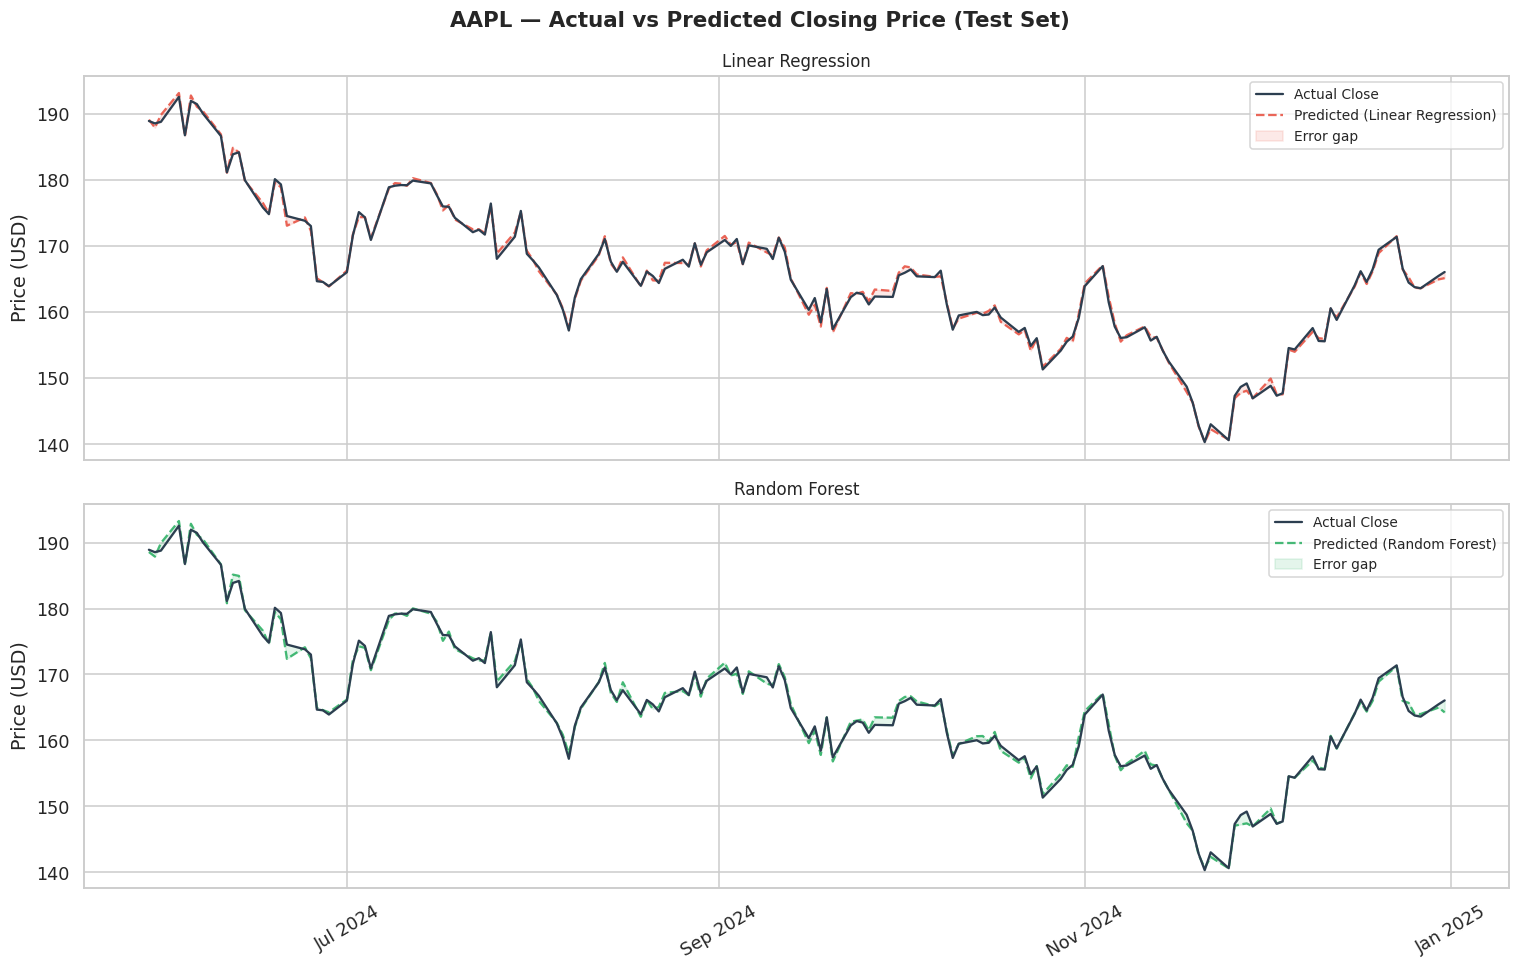

In [11]:
test_dates = X_test.index

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
fig.suptitle('AAPL — Actual vs Predicted Closing Price (Test Set)', fontsize=14, fontweight='bold')

for ax, preds, title, color in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ['Linear Regression', 'Random Forest'],
    ['#e74c3c', '#27ae60']
):
    ax.plot(test_dates, y_test.values, color='#2c3e50', linewidth=1.5,
            label='Actual Close', zorder=3)
    ax.plot(test_dates, preds, color=color, linewidth=1.5, linestyle='--',
            alpha=0.85, label=f'Predicted ({title})', zorder=2)
    ax.fill_between(test_dates, y_test.values, preds,
                    alpha=0.12, color=color, label='Error gap')

    ax.set_ylabel('Price (USD)')
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', bbox_inches='tight')
plt.show()

### Zoomed in view — last 60 trading days

Let's zoom into the most recent part to see the prediction quality more clearly.

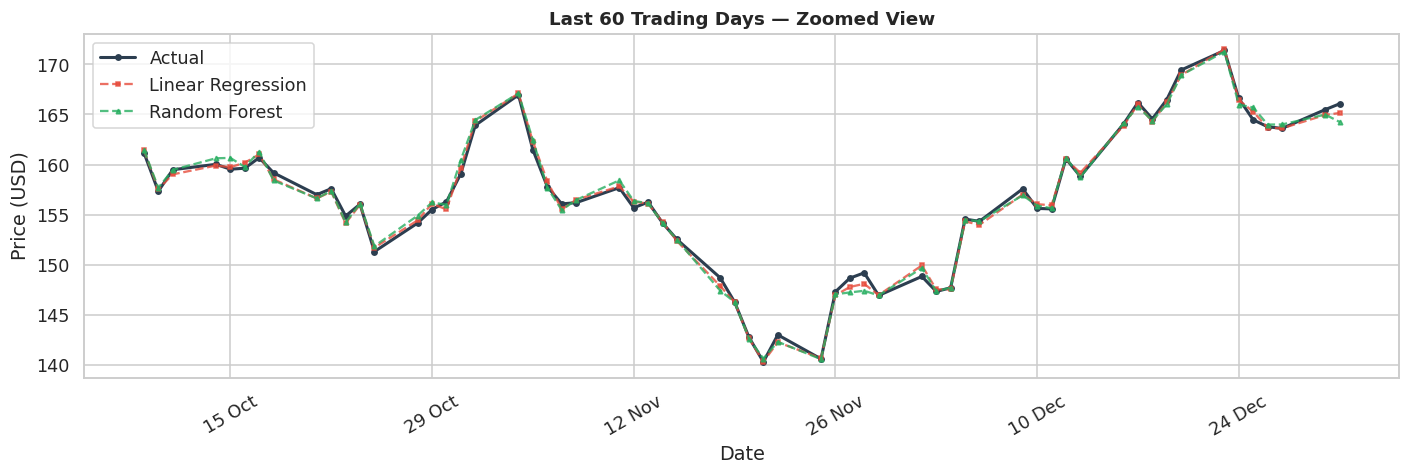

In [12]:
n = 60  # last 60 trading days

fig, ax = plt.subplots(figsize=(13, 4.5))

ax.plot(test_dates[-n:], y_test.values[-n:], 'o-', color='#2c3e50',
        linewidth=2, markersize=3.5, label='Actual')
ax.plot(test_dates[-n:], y_pred_lr[-n:], 's--', color='#e74c3c',
        linewidth=1.5, markersize=3, alpha=0.8, label='Linear Regression')
ax.plot(test_dates[-n:], y_pred_rf[-n:], '^--', color='#27ae60',
        linewidth=1.5, markersize=3, alpha=0.8, label='Random Forest')

ax.set_title('Last 60 Trading Days — Zoomed View', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('zoomed_predictions.png', bbox_inches='tight')
plt.show()

## Error Distribution

Let's also look at the distribution of prediction errors (actual - predicted). Ideally they should be centered around 0 with no big skew.

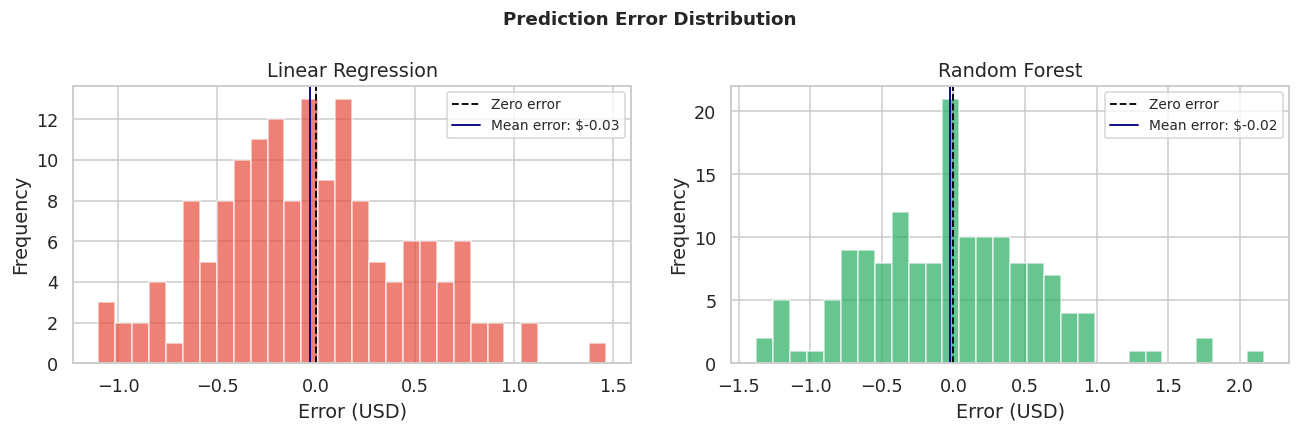

In [13]:
err_lr = y_test.values - y_pred_lr
err_rf = y_test.values - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Prediction Error Distribution', fontsize=12, fontweight='bold')

for ax, errs, title, color in zip(
    axes,
    [err_lr, err_rf],
    ['Linear Regression', 'Random Forest'],
    ['#e74c3c', '#27ae60']
):
    ax.hist(errs, bins=30, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(0, color='black', linestyle='--', linewidth=1.2, label='Zero error')
    ax.axvline(errs.mean(), color='navy', linestyle='-', linewidth=1.2,
               label=f'Mean error: ${errs.mean():.2f}')
    ax.set_title(title)
    ax.set_xlabel('Error (USD)')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('error_distribution.png', bbox_inches='tight')
plt.show()

## Feature Importance (Random Forest)

One cool thing about Random Forest is it can tell you which features it found most useful. Let's check that out.

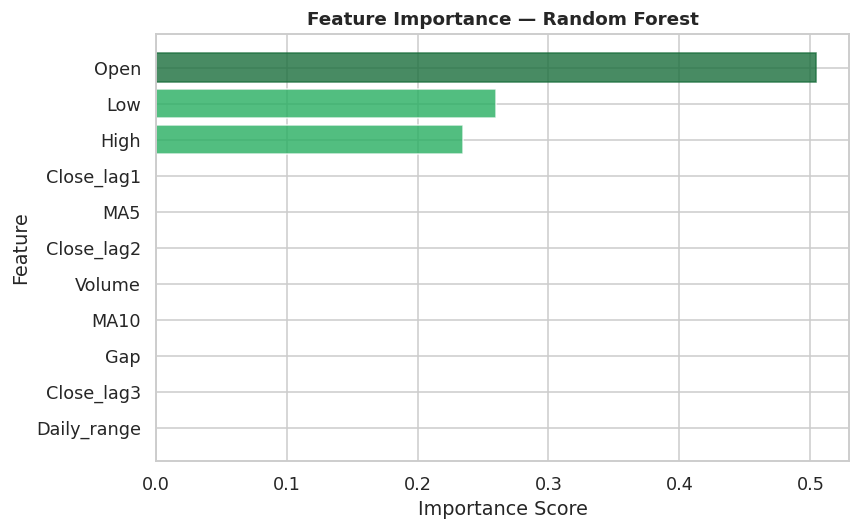


Top 3 most important features:
High    0.2344
Low     0.2600
Open    0.5046
dtype: float64


In [14]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(importances.index, importances.values, color='#27ae60', alpha=0.8, edgecolor='white')

# highlight the top feature
top_idx = importances.values.argmax()
bars[top_idx].set_color('#1a6e3c')

ax.set_title('Feature Importance — Random Forest', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

print('\nTop 3 most important features:')
print(importances.tail(3).round(4))

## Final Results Summary

In [15]:
print('='*45)
print('          FINAL MODEL COMPARISON')
print('='*45)
print(f"{'Metric':<20} {'Lin. Reg':>10} {'Rnd. Forest':>12}")
print('-'*45)
print(f"{'MAE ($)':<20} {mae_lr:>10.2f} {mae_rf:>12.2f}")
print(f"{'RMSE ($)':<20} {rmse_lr:>10.2f} {rmse_rf:>12.2f}")
print(f"{'R² Score':<20} {r2_lr:>10.4f} {r2_rf:>12.4f}")
print('='*45)

winner = 'Random Forest' if r2_rf > r2_lr else 'Linear Regression'
print(f'\nBetter model: {winner}')

          FINAL MODEL COMPARISON
Metric                 Lin. Reg  Rnd. Forest
---------------------------------------------
MAE ($)                    0.39         0.48
RMSE ($)                   0.49         0.62
R² Score                 0.9979       0.9967

Better model: Linear Regression


## What I learned from this task

**Random Forest clearly outperformed Linear Regression** — the R² score is higher and the errors are smaller. This makes sense because stock prices don't move in a perfectly linear way.

The most important feature was `Close_lag1` (yesterday's close price) — which makes total sense. The best predictor of today's price is almost always yesterday's price. The rolling averages (MA5, MA10) also ranked high, confirming that short-term trend matters.

**A few things worth keeping in mind though:**
- This model is technically "cheating" a little — in real life, you don't know today's High/Low/Volume when trying to predict the close at market open. A more realistic setup would use only yesterday's data
- Stock prices are notoriously hard to predict. Even a high R² here doesn't mean you'd make money trading on this
- This model would need to be retrained regularly as market conditions change

Still, as a learning exercise, this covers all the key steps: feature engineering on time series data, building two different models, evaluating with proper metrics, and plotting results clearly.